#📌 Extracción

In [132]:
import pandas as pd
import matplotlib.pyplot as plt

In [133]:
datos = pd.read_json('TelecomX_Data.json')

In [134]:
datos

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformación

In [135]:
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [136]:
##Explorar las columnas del dataset y verificar sus tipos de datos.
datos.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [137]:
##Consultar el diccionario para comprender mejor el significado de las variables.
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [138]:
##Identificar las columnas más relevantes para el análisis de evasión.
datos['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [139]:
##Normalizamos los datos
datos = pd.json_normalize(datos.to_dict(orient='records'))

In [140]:
datos

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [141]:
##Verificamos si existen datos nulos
datos.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [142]:
##Verificamos si hay registros duplicados
datos.duplicated().sum()

np.int64(0)

In [143]:
##Calculamos el número de celdas en blanco
datos.astype(str).apply(lambda x: x.str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [144]:
##Eliminamos las celdas en blanco
datos = datos[(datos != " ").all(axis=1)]
datos = datos[(datos != ' ').all(axis=1)]
datos = datos[(datos != '').all(axis=1)]

In [145]:
datos.shape

(7032, 21)

In [146]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   object 
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   object 
 1

In [147]:
##Convertir la columna account.Charges.Total en float
datos['account.Charges.Total'] = datos['account.Charges.Total'].astype(float)

In [148]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   object 
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   object 
 1

#📊 Carga y análisis

In [149]:
##Realizamos un análisis descriptivo
datos.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


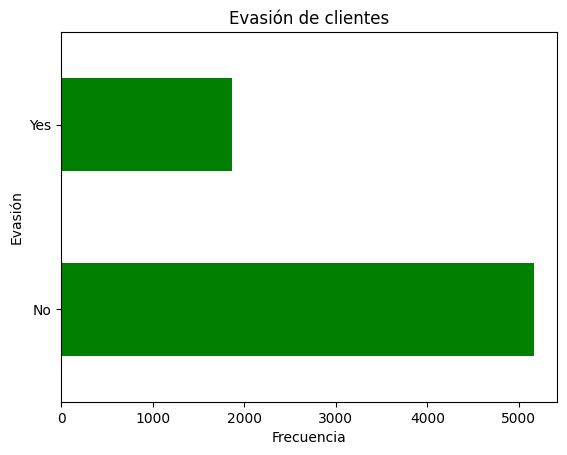

In [150]:
##Creamos el grafico evasión de clientes (churn)
datos['Churn'].value_counts().plot(kind='barh',color='green')
plt.title('Evasión de clientes')
plt.ylabel('Evasión')
plt.xlabel('Frecuencia')
plt.show()

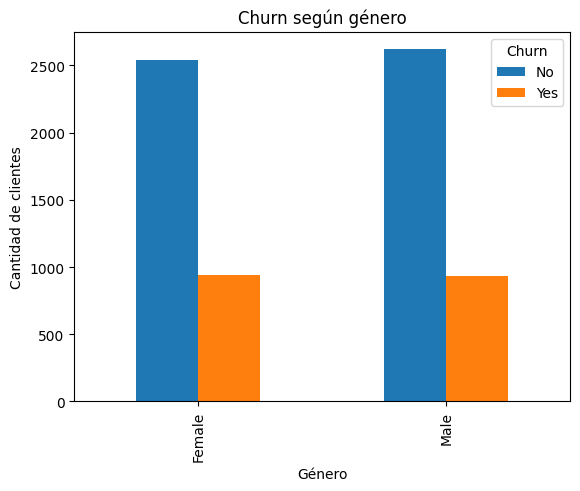

In [151]:
##Grafico de numero de evasion segun el genero
tabla_genero = pd.crosstab(datos['customer.gender'], datos['Churn'])

tabla_genero.plot(kind='bar')

plt.title('Churn según género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')

plt.show()

Text(0, 0.5, 'Cantidad de clientes')

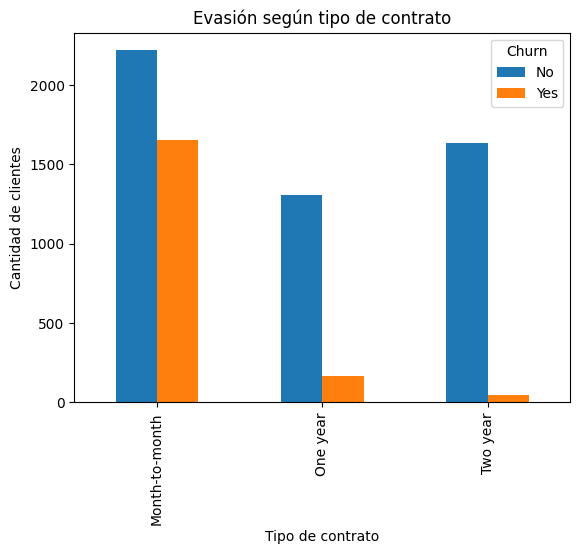

In [152]:
##Grafico de numero de evasion segun el tipo de contrato
tabla_contrato = pd.crosstab(datos['account.Contract'], datos['Churn'])
tabla_contrato.plot(kind='bar')
plt.title('Evasión según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')

Text(0, 0.5, 'Cantidad de clientes')

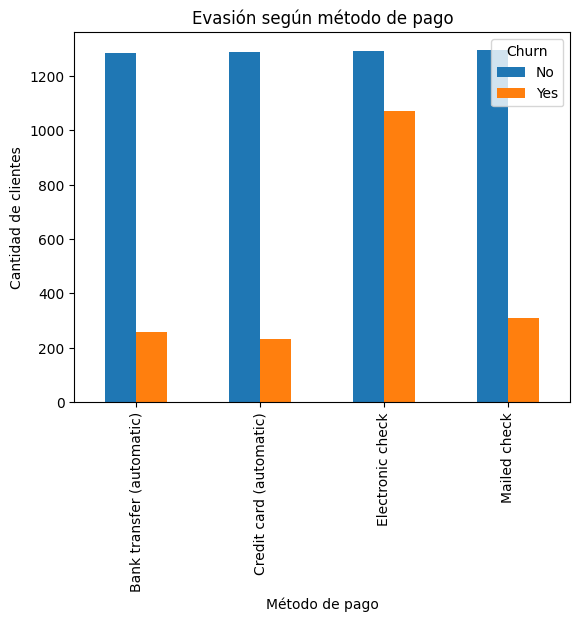

In [153]:
##Grafico de numero de evasion segun el método de pago
tabla_pago = pd.crosstab(datos['account.PaymentMethod'], datos['Churn'])
tabla_pago.plot(kind='bar')
plt.title('Evasión según método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Cantidad de clientes')

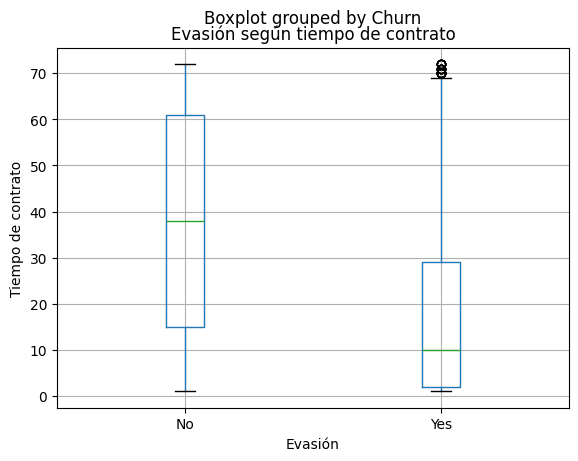

In [154]:
##Grafico de evasion segun tiempo de contrato
datos.boxplot(column='customer.tenure', by='Churn')
plt.title('Evasión según tiempo de contrato')
plt.xlabel('Evasión')
plt.ylabel('Tiempo de contrato')
plt.show()

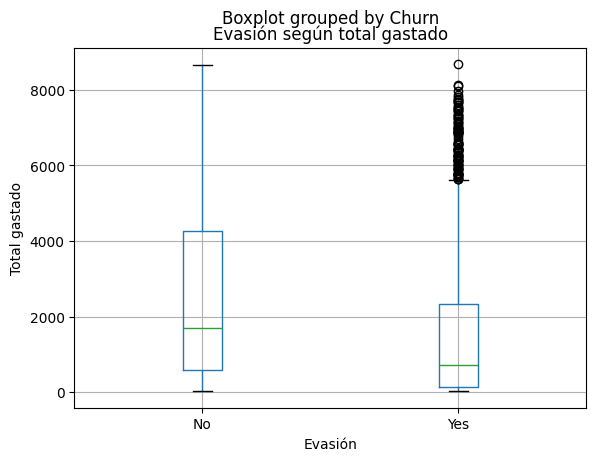

In [155]:
##Grafico de evasion segun total gastado
datos.boxplot(column='account.Charges.Total', by='Churn')
plt.title('Evasión según total gastado')
plt.xlabel('Evasión')
plt.ylabel('Total gastado')
plt.show()

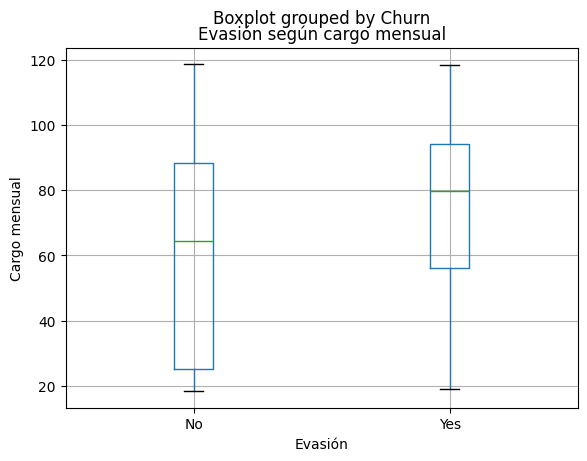

In [156]:
##Grafico de evasion segun cargo mensual
datos.boxplot(column='account.Charges.Monthly', by='Churn')
plt.title('Evasión según cargo mensual')
plt.xlabel('Evasión')
plt.ylabel('Cargo mensual')
plt.show()

#📄Informe final

##INFORME FINAL - TELECOM X

###ANÁLISIS DE EVASIÓN DE CLIENTES (CHURN) EN TELECOM X

####INTRODUCCIÓN

La evasión de clientes, conocida como Churn, es uno de los principales desafíos para las empresas
de telecomunicaciones, ya que representa la pérdida de usuarios que dejan de utilizar los servicios
ofrecidos. Comprender las razones detrás de este fenómeno es fundamental para mejorar la
retención de clientes y optimizar las estrategias comerciales.

El objetivo de este análisis es explorar el comportamiento de los clientes de TelecomX utilizando
análisis exploratorio de datos para identificar patrones relacionados con la cancelación del servicio.
Se analizaron variables demográficas, contractuales y de consumo con el fin de determinar cuáles
factores influyen en la evasión de clientes.

####LIMPIEZA Y TRATAMIENTO DE DATOS

Para garantizar la calidad del análisis, se realizaron varios procesos de preparación de datos.

Primero se importó el dataset en formato JSON utilizando la biblioteca pandas de Python.
Posteriormente se normalizó la estructura del dataset para transformar los datos anidados en
columnas analizables.

Durante la limpieza de datos se realizaron las siguientes acciones:

• Identificación de valores nulos y celdas vacías
• Eliminación de registros con información incompleta
• Verificación de registros duplicados
• Conversión de variables numéricas que estaban almacenadas como texto
• Estandarización de categorías para evitar inconsistencias en los valores

Estas transformaciones permitieron trabajar con un dataset limpio y consistente, lo que facilita
la realización de análisis exploratorios y visualizaciones confiables.

####ANÁLISIS EXPLORATORIO DE DATOS

Se realizaron diversos análisis para comprender cómo se distribuye la evasión de clientes y qué
variables pueden estar relacionadas con este fenómeno.

Distribución de Churn:

El primer análisis consistió en observar la distribución de clientes que permanecen en el servicio
y aquellos que cancelaron su suscripción. Los resultados muestran que aproximadamente entre
el 70% y 75% de los clientes continúan utilizando los servicios de TelecomX, mientras que
alrededor del 25% al 30% de los clientes han cancelado el servicio.

Esto indica que existe una proporción considerable de evasión que podría afectar los ingresos
de la empresa si no se implementan estrategias de retención.

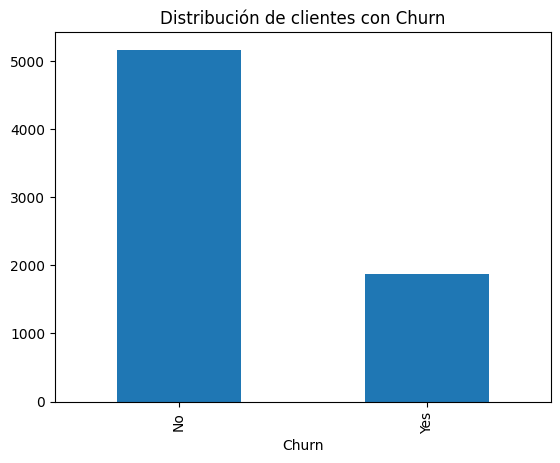

In [157]:
datos['Churn'].value_counts().plot(kind='bar')
plt.title('Distribución de clientes con Churn')
plt.show()

####ANÁLISIS DE VARIABLES CATEGÓRICAS

Posteriormente se analizaron variables categóricas como el género del cliente,
el tipo de contrato y el método de pago.

Tipo de contrato:

El análisis muestra que los clientes con contratos mensuales (Month-to-Month)
presentan una mayor tendencia a cancelar el servicio. En contraste, los clientes
con contratos de uno o dos años presentan una tasa de evasión significativamente
menor.

Esto sugiere que los compromisos contractuales más largos generan una mayor
estabilidad en la relación entre el cliente y la empresa.

Método de pago:

También se observó que los clientes que utilizan el método de pago "Electronic Check"
presentan una mayor proporción de cancelaciones en comparación con otros métodos
de pago como tarjetas de crédito o transferencias bancarias.

Género:

En el caso del género, no se observaron diferencias significativas entre hombres
y mujeres en relación con la evasión de clientes.

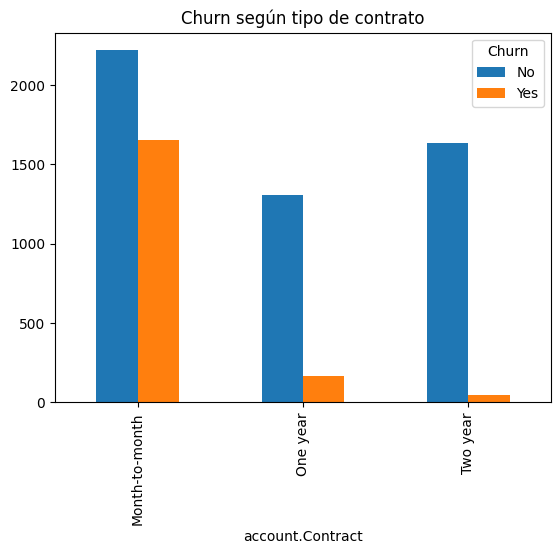

In [158]:
pd.crosstab(datos['account.Contract'], datos['Churn']).plot(kind='bar')
plt.title('Churn según tipo de contrato')
plt.show()

####ANÁLISIS DE VARIABLES NUMÉRICAS

También se analizaron variables numéricas como el tiempo de permanencia del cliente
(tenure), los cargos mensuales y el total gastado.

Tiempo de permanencia (Tenure):

Los resultados muestran que los clientes que cancelan el servicio suelen tener un
menor tiempo de permanencia en la empresa. Esto indica que la evasión ocurre con
mayor frecuencia durante los primeros meses del servicio.

Cargo mensual:

El análisis también sugiere que algunos clientes con cargos mensuales más altos
presentan una mayor probabilidad de cancelar el servicio, lo que podría indicar
una percepción de alto costo o falta de valor en el servicio ofrecido.

Total gastado:

Se observó que los clientes que permanecen en la empresa tienden a tener un mayor
gasto total acumulado, lo cual es consistente con su mayor tiempo de permanencia.


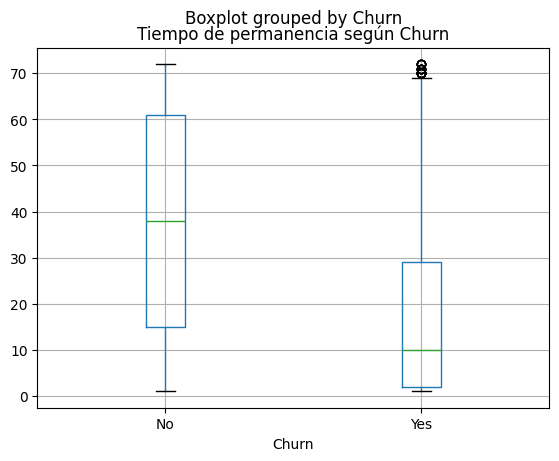

In [159]:
datos.boxplot(column='customer.tenure', by='Churn')
plt.title('Tiempo de permanencia según Churn')
plt.show()

####CONCLUSIONES E INSIGHTS

A partir del análisis realizado se identificaron varios factores importantes
relacionados con la evasión de clientes.

Uno de los factores más relevantes es el tipo de contrato. Los clientes con
contratos mensuales presentan una mayor probabilidad de cancelar el servicio.

También se identificó que los clientes con menor tiempo de permanencia tienen
mayor tendencia a abandonar el servicio, lo que sugiere que la empresa debería
prestar especial atención a la experiencia de los nuevos clientes.

Asimismo, los cargos mensuales elevados podrían estar relacionados con una mayor
probabilidad de cancelación, lo que indica la importancia de mantener una buena
relación entre precio y valor percibido por el cliente.

####RECOMENDACIONES

Con base en los hallazgos del análisis, se proponen las siguientes acciones
estratégicas para reducir la evasión de clientes:

1. Incentivar contratos de largo plazo mediante descuentos o beneficios
   adicionales para los clientes que elijan contratos anuales o bianuales.

2. Implementar estrategias de fidelización dirigidas a clientes nuevos,
   especialmente durante los primeros meses del servicio.

3. Revisar la estructura de precios y evaluar si los cargos mensuales están
   alineados con el valor percibido por los clientes.

4. Promover métodos de pago automáticos o más estables que reduzcan el riesgo
   de cancelación.

5. Implementar modelos predictivos de churn en el futuro para identificar
   clientes con alto riesgo de cancelación y aplicar estrategias de retención
   antes de que abandonen el servicio.

Estas acciones podrían ayudar a TelecomX a mejorar la retención de clientes
y reducir el impacto financiero asociado con la evasión.

##Guardamos el Dataframe limpio

In [160]:
datos.to_csv("datos_tratados.csv", index=False)

# ***Challenge TelecomX parte 2***

#🛠️ Preparación de los Datos

In [161]:
datos = pd.read_csv('datos_tratados.csv')

datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [162]:
#Eliminación de Columnas Irrelevantes
datos = datos.drop('customerID', axis=1)

datos.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [163]:
#Encoding
columnas_categoricas = datos.select_dtypes(include=['object']).columns
datos = pd.get_dummies(datos, columns=columnas_categoricas)
datos = datos.astype(int)
datos.head()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Churn_No,Churn_Yes,customer.gender_Female,customer.gender_Male,customer.Partner_No,customer.Partner_Yes,...,internet.StreamingMovies_Yes,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_No,account.PaperlessBilling_Yes,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65,593,1,0,1,0,0,1,...,0,0,1,0,0,1,0,0,0,1
1,0,9,59,542,1,0,0,1,1,0,...,1,1,0,0,1,0,0,0,0,1
2,0,4,73,280,0,1,0,1,1,0,...,0,1,0,0,0,1,0,0,1,0
3,1,13,98,1237,0,1,0,1,0,1,...,1,1,0,0,0,1,0,0,1,0
4,1,3,83,267,0,1,1,0,0,1,...,0,1,0,0,0,1,0,0,0,1


In [164]:
#Verificación de la Proporción de Cancelación (Churn)
cancelaron = datos['Churn_Yes'].sum()
total_clientes = len(datos)

proporcion_cancelaron = cancelaron / total_clientes
proporcion_activos = 1 - proporcion_cancelaron

print(f"Clientes que cancelaron: {round(proporcion_cancelaron,3)*100}%")
print(f"Clientes activos: {round(proporcion_activos,3)*100}%")

Clientes que cancelaron: 26.6%
Clientes activos: 73.4%


In [165]:
#Normalización o Estandarización
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
columnas_numericas = datos.select_dtypes(include=['int64','float64']).columns
datos[columnas_numericas] = scaler.fit_transform(datos[columnas_numericas])
datos.head()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Churn_No,Churn_Yes,customer.gender_Female,customer.gender_Male,customer.Partner_No,customer.Partner_Yes,...,internet.StreamingMovies_Yes,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_No,account.PaperlessBilling_Yes,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,-0.440327,-0.954296,0.022187,-0.745533,0.601663,-0.601663,1.009430,-1.009430,-1.035617,1.035617,...,-0.796849,-1.107895,1.943495,-0.561364,-0.828939,0.828939,-0.529976,-0.525351,-0.711863,1.839576
1,-0.440327,-0.954296,-0.177238,-0.768034,0.601663,-0.601663,-0.990658,0.990658,0.965608,-0.965608,...,1.254943,0.902613,-0.514537,-0.561364,1.206361,-1.206361,-0.529976,-0.525351,-0.711863,1.839576
2,-0.440327,-1.158016,0.288086,-0.883625,-1.662059,1.662059,-0.990658,0.990658,0.965608,-0.965608,...,-0.796849,0.902613,-0.514537,-0.561364,-0.828939,0.828939,-0.529976,-0.525351,1.404764,-0.543604
3,2.271039,-0.791321,1.119023,-0.461408,-1.662059,1.662059,-0.990658,0.990658,-1.035617,1.035617,...,1.254943,0.902613,-0.514537,-0.561364,-0.828939,0.828939,-0.529976,-0.525351,1.404764,-0.543604
4,2.271039,-1.198760,0.620461,-0.889360,-1.662059,1.662059,1.009430,-1.009430,-1.035617,1.035617,...,-0.796849,0.902613,-0.514537,-0.561364,-0.828939,0.828939,-0.529976,-0.525351,-0.711863,1.839576


#🎯 Correlación y Selección de Variables

In [166]:
#Análisis de Correlación
matriz_corr = datos.corr()
matriz_corr

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Churn_No,Churn_Yes,customer.gender_Female,customer.gender_Male,customer.Partner_No,customer.Partner_Yes,...,internet.StreamingMovies_Yes,account.Contract_Month-to-month,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_No,account.PaperlessBilling_Yes,account.PaymentMethod_Bank transfer (automatic),account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
customer.SeniorCitizen,1.000000,0.015683,0.219829,0.102412,-0.150541,0.150541,0.001819,-0.001819,-0.016957,0.016957,...,0.119842,0.137752,-0.046491,-0.116205,-0.156258,0.156258,-0.016235,-0.024359,0.171322,-0.152987
customer.tenure,0.015683,1.000000,0.246876,0.825881,0.354049,-0.354049,-0.005285,0.005285,-0.381912,0.381912,...,0.285402,-0.649346,0.202338,0.563801,-0.004823,0.004823,0.243822,0.232800,-0.210197,-0.232181
account.Charges.Monthly,0.219829,0.246876,1.000000,0.651125,-0.192922,0.192922,0.014095,-0.014095,-0.097890,0.097890,...,0.627228,0.058857,0.004886,-0.073241,-0.351923,0.351923,0.042099,0.030277,0.271238,-0.376615
account.Charges.Total,0.102412,0.825881,0.651125,1.000000,0.199485,-0.199485,-0.000049,0.000049,-0.319071,0.319071,...,0.519868,-0.446775,0.170567,0.358037,-0.157830,0.157830,0.186118,0.182664,-0.060436,-0.294708
Churn_No,-0.150541,0.354049,-0.192922,0.199485,1.000000,-1.000000,-0.008545,0.008545,-0.149982,0.149982,...,-0.060860,-0.404565,0.178225,0.301552,0.191454,-0.191454,0.118136,0.134687,-0.301455,0.090773
Churn_Yes,0.150541,-0.354049,0.192922,-0.199485,-1.000000,1.000000,0.008545,-0.008545,0.149982,-0.149982,...,0.060860,0.404565,-0.178225,-0.301552,-0.191454,0.191454,-0.118136,-0.134687,0.301455,-0.090773
customer.gender_Female,0.001819,-0.005285,0.014095,-0.000049,-0.008545,0.008545,1.000000,-1.000000,-0.001379,0.001379,...,0.010105,0.003251,-0.007755,0.003603,-0.011902,0.011902,0.015973,-0.001632,-0.000844,-0.013199
customer.gender_Male,-0.001819,0.005285,-0.014095,0.000049,0.008545,-0.008545,-1.000000,1.000000,0.001379,-0.001379,...,-0.010105,-0.003251,0.007755,-0.003603,0.011902,-0.011902,-0.015973,0.001632,0.000844,0.013199
customer.Partner_No,-0.016957,-0.381912,-0.097890,-0.319071,-0.149982,0.149982,-0.001379,0.001379,1.000000,-1.000000,...,-0.118108,0.280202,-0.083067,-0.247334,-0.013957,0.013957,-0.111406,-0.082327,0.083207,0.096948
customer.Partner_Yes,0.016957,0.381912,0.097890,0.319071,0.149982,-0.149982,0.001379,-0.001379,-1.000000,1.000000,...,0.118108,-0.280202,0.083067,0.247334,0.013957,-0.013957,0.111406,0.082327,-0.083207,-0.096948


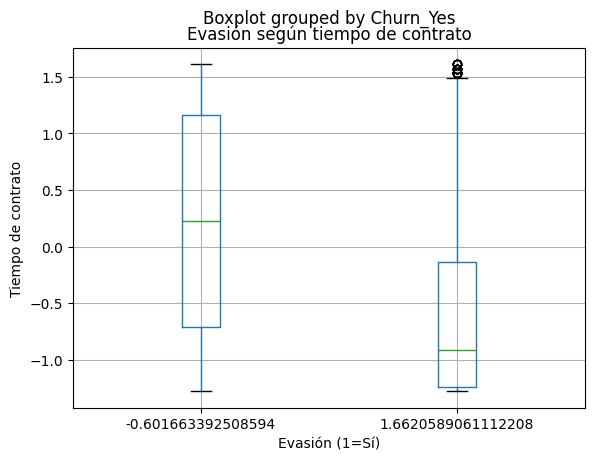

In [167]:
#Análisis Dirigido
datos.boxplot(column='customer.tenure', by='Churn_Yes')
plt.title('Evasión según tiempo de contrato')
plt.xlabel('Evasión (1=Sí)')
plt.ylabel('Tiempo de contrato')
plt.show()

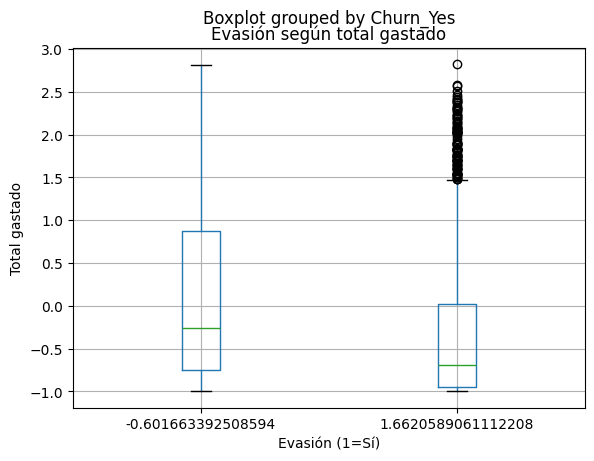

In [168]:
datos.boxplot(column='account.Charges.Total', by='Churn_Yes')
plt.title('Evasión según total gastado')
plt.xlabel('Evasión (1=Sí)')
plt.ylabel('Total gastado')
plt.show()

#🤖 Modelado Predictivo

In [169]:
#Separación de Datos
from sklearn.model_selection import train_test_split

X = datos.drop(['Churn_No', 'Churn_Yes'], axis=1)
y = datos['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [170]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [171]:
#Modelo Regresion Logistica
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_regresion_logistica = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo_regresion_logistica.fit(X_train_scaled, y_train)
y_pred_regresion_logistica = modelo_regresion_logistica.predict(X_test_scaled)
print(classification_report(y_test, y_pred_regresion_logistica))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [172]:
#Modelo Arbol
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

modelo_arbol = DecisionTreeClassifier(class_weight='balanced', random_state=42)
modelo_arbol.fit(X_train, y_train)
y_pred_arbol = modelo_arbol.predict(X_test)
print(classification_report(y_test, y_pred_arbol))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1033
           1       0.49      0.48      0.49       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407



In [173]:
#Evaluación de los Modelos
from sklearn.metrics import confusion_matrix

print("Resultados - Regresión Logística")
print(classification_report(y_test, y_pred_regresion_logistica))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_regresion_logistica))

Resultados - Regresión Logística
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407

Matriz de confusión:
[[732 301]
 [ 82 292]]


In [174]:
print("Resultados - Árbol de Decisión")
print(classification_report(y_test, y_pred_arbol))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_arbol))

Resultados - Árbol de Decisión
              precision    recall  f1-score   support

           0       0.81      0.82      0.81      1033
           1       0.49      0.48      0.49       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407

Matriz de confusión:
[[843 190]
 [193 181]]


#📋 Interpretación y Conclusiones

In [175]:
#Análisis de la Importancia de las Variables
import pandas as pd

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_regresion_logistica.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

print(coeficientes.head(10))

                                  Variable  Coeficiente
3                    account.Charges.Total     0.743881
36         account.Contract_Month-to-month     0.340338
16    internet.InternetService_Fiber optic     0.330925
43  account.PaymentMethod_Electronic check     0.137320
35            internet.StreamingMovies_Yes     0.133012
32                internet.StreamingTV_Yes     0.130481
18              internet.OnlineSecurity_No     0.106181
27                 internet.TechSupport_No     0.088609
0                   customer.SeniorCitizen     0.082935
40            account.PaperlessBilling_Yes     0.081324


In [176]:
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_arbol.feature_importances_
})

importancia = importancia.sort_values(by='Importancia', ascending=False)

print(importancia.head(10))

                                  Variable  Importancia
36         account.Contract_Month-to-month     0.247361
3                    account.Charges.Total     0.178502
1                          customer.tenure     0.129594
2                  account.Charges.Monthly     0.096208
16    internet.InternetService_Fiber optic     0.051497
39             account.PaperlessBilling_No     0.019372
0                   customer.SeniorCitizen     0.016271
9                  customer.Dependents_Yes     0.015944
43  account.PaymentMethod_Electronic check     0.015679
6                      customer.Partner_No     0.013723


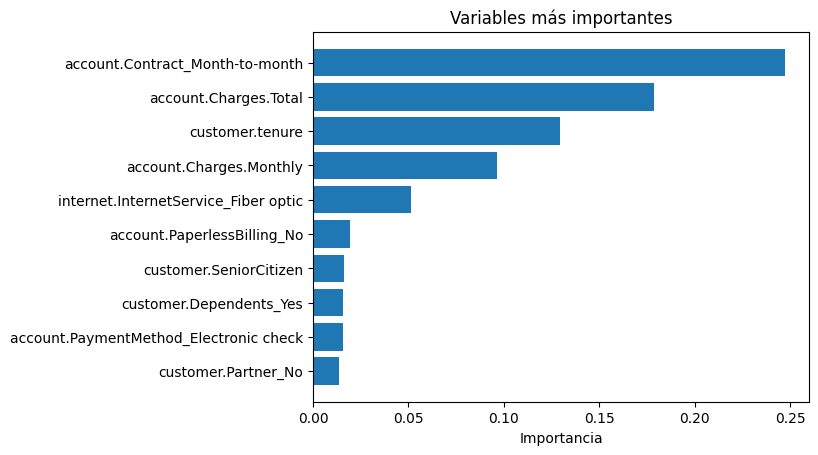

In [177]:
import matplotlib.pyplot as plt

top_variables = importancia.head(10)

plt.barh(top_variables['Variable'], top_variables['Importancia'])
plt.title("Variables más importantes")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()

plt.show()

##📊INFORME FINAL - TELECOM X Parte 2

###1. Introducción

En esta segunda parte del Challenge TelecomX, el objetivo fue ir más allá del análisis exploratorio y construir modelos predictivos capaces de anticipar qué clientes tienen mayor probabilidad de cancelar el servicio.

El dataset analizado contiene aproximadamente 7032 clientes, junto con información relacionada con:

* características del cliente

* tipo de contrato

* servicios contratados

* método de pago

* cargos mensuales y totales

La variable principal analizada fue Churn, que indica si un cliente canceló o no el servicio.

Para abordar este problema se utilizaron dos modelos de machine learning:

* Regresión Logística

* Árbol de Decisión

Cada modelo permite identificar patrones ocultos en los datos y descubrir qué factores influyen más en la cancelación.

###🤖 2. Modelos predictivos utilizados

####🔹 Regresión Logística

Este modelo calcula la probabilidad de que un cliente cancele el servicio en función de las variables del dataset.

Ventajas:

* Permite interpretar cómo cada variable influye en la cancelación.

* Ideal para problemas de clasificación binaria como el churn.


####🌳 Árbol de Decisión

El árbol de decisión divide los datos en diferentes ramas según las variables más importantes.

Ventajas:

* Es fácil de interpretar

* Identifica rápidamente las variables más influyentes en la cancelación

##📈 3. Distribución de cancelación de clientes

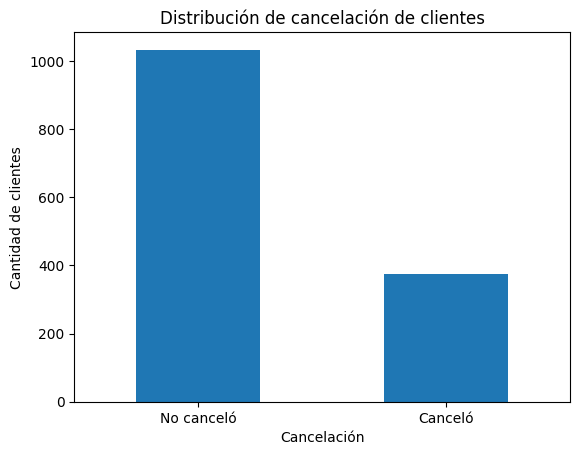

In [179]:
import matplotlib.pyplot as plt

cancelacion = y_test.astype(int)

cancelacion.value_counts().plot(kind='bar')

plt.title("Distribución de cancelación de clientes")
plt.xlabel("Cancelación")
plt.ylabel("Cantidad de clientes")
plt.xticks([0,1], ["No canceló","Canceló"], rotation=0)

plt.show()

📊 Interpretación

Los datos muestran que aproximadamente:

73% de los clientes permanecen activos

27% de los clientes cancelan el servicio

Esto indica que existe un desbalance de clases, algo común en problemas de churn.

##🔎 4. Factores que más influyen en la cancelación
Los modelos permitieron identificar las variables más importantes para predecir la cancelación.

###⏱️ Factor 1: Tiempo como cliente (Tenure)

Uno de los factores más claros es el tiempo que un cliente lleva con la empresa.

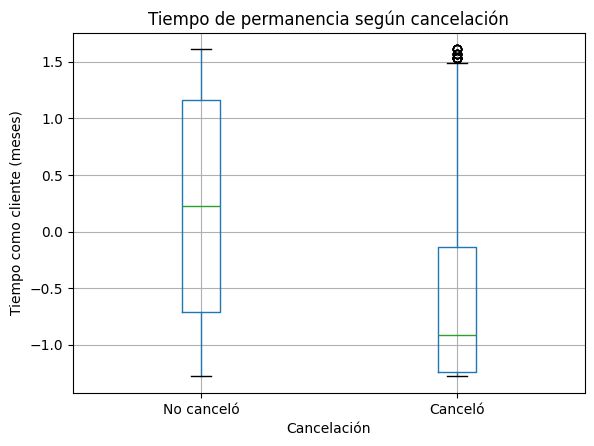

In [185]:
import matplotlib.pyplot as plt

datos['Cancelacion'] = datos['Churn_Yes'].astype(int)

datos.boxplot(column='customer.tenure', by='Cancelacion')

plt.suptitle('')
plt.title("Tiempo de permanencia según cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo como cliente (meses)")
plt.xticks([1,2], ["No canceló","Canceló"])

plt.show()

###💰 Factor 2: Gasto total del cliente

El gasto acumulado también muestra una relación interesante con la cancelación.

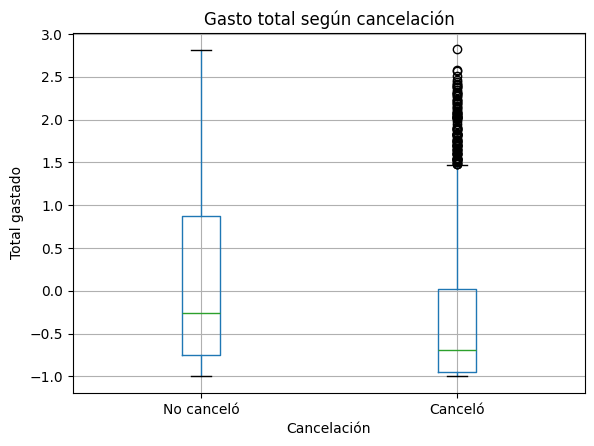

In [186]:
datos.boxplot(column='account.Charges.Total', by='Cancelacion')

plt.suptitle('')
plt.title("Gasto total según cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Total gastado")
plt.xticks([1,2], ["No canceló","Canceló"])

plt.show()

📊 Interpretación

Los clientes que cancelan generalmente presentan menor gasto total acumulado.

Esto ocurre porque:

muchos clientes cancelan antes de permanecer mucho tiempo en la empresa

En cambio, los clientes que permanecen generan mayor valor a largo plazo.

###📄 Factor 3: Tipo de contrato

Otro factor importante es el tipo de contrato.

Los clientes con contrato Month-to-Month presentan una mayor tasa de cancelación en comparación con contratos de:

* One year

* Two year

Esto sugiere que:

👉 Los contratos a largo plazo generan mayor estabilidad y fidelización.

###💳 Factor 4: Método de pago

Los datos muestran que clientes que utilizan Electronic Check presentan mayores tasas de cancelación.

Esto podría indicar:

*menor compromiso con el servicio

*menor automatización de pagos

###🧩 Factor 5: Servicios adicionales

Los clientes que no cuentan con servicios adicionales, como:

* soporte técnico

* seguridad en línea

* respaldo en la nube

* tienen mayor probabilidad de cancelar.

Estos servicios aumentan el valor percibido del servicio y ayudan a fidelizar al cliente.

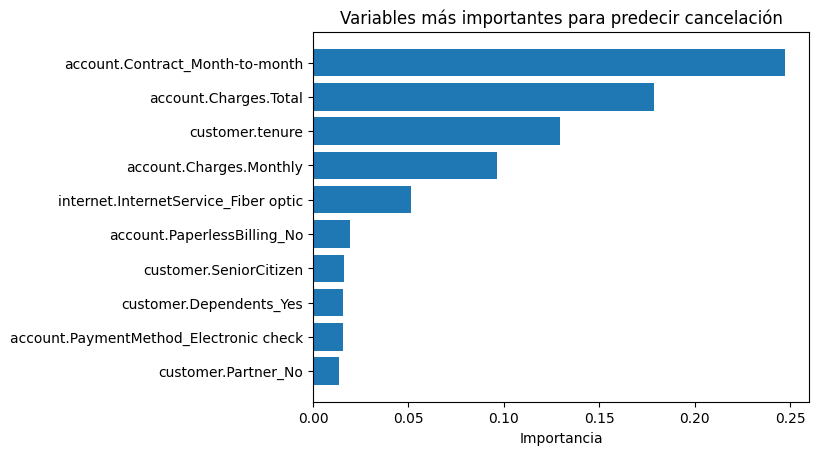

In [189]:
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_arbol.feature_importances_
})

importancia = importancia.sort_values(by='Importancia', ascending=False)

top = importancia.head(10)

plt.barh(top['Variable'], top['Importancia'])

plt.title("Variables más importantes para predecir cancelación")
plt.xlabel("Importancia")

plt.gca().invert_yaxis()

plt.show()

###💡 Estrategias para reducir la cancelación

A partir del análisis realizado, TelecomX podría implementar varias estrategias para mejorar la retención de clientes.

🎯 1. Programas de fidelización para clientes nuevos

Los clientes con menor antigüedad presentan mayor riesgo de cancelación.

Se recomienda:

* promociones durante los primeros meses

* seguimiento personalizado

* incentivos de permanencia

📄 2. Incentivar contratos de largo plazo

Ofrecer beneficios como:

* descuentos por contrato anual

* servicios adicionales incluidos

podría reducir la tasa de cancelación.

💰 3. Optimizar la estructura de precios

Los clientes con altos cargos mensuales presentan mayor probabilidad de cancelar.

TelecomX podría:

* ofrecer planes más flexibles

* ajustar precios según uso real del cliente

⭐ 4. Promover servicios adicionales

Servicios complementarios aumentan el valor del producto.

Promocionar:

* soporte técnico

* seguridad digital

* almacenamiento en la nube

puede mejorar la fidelización.

##🧠 Conclusión final

El análisis predictivo desarrollado en el Challenge TelecomX – Parte 2 permitió identificar patrones clave que explican la cancelación de clientes.

Los modelos de machine learning revelaron que variables como tiempo de permanencia, tipo de contrato, gasto mensual y servicios adicionales tienen un impacto significativo en la probabilidad de churn.

Los clientes nuevos, con contratos mensuales y menor inversión en servicios adicionales presentan mayor riesgo de cancelar el servicio.

Gracias a estos hallazgos, TelecomX puede anticipar qué clientes están en riesgo y aplicar estrategias de retención antes de que se produzca la cancelación. Esto no solo permite reducir la pérdida de clientes, sino también maximizar el valor a largo plazo de cada usuario.

En un mercado altamente competitivo como el de telecomunicaciones, el uso de analítica de datos y modelos predictivos se convierte en una herramienta clave para mejorar la toma de decisiones y fortalecer la relación con los clientes.